In [6]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.io import fits
import matplotlib.pyplot as plt

In [22]:
image = '../src/cutouts/src_00014.fits'
file = fits.open(image)

In [23]:
file.info()

Filename: ../src/cutouts/src_00014.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      17   ()      
  1  SCI           1 ImageHDU        39   (90, 90)   float32   
  2  ERR           1 ImageHDU        39   (90, 90)   float32   
  3  SEGMAP        1 ImageHDU        39   (90, 90)   int32   
  4  MASK          1 ImageHDU        39   (90, 90)   uint8   


In [24]:
sci = file["SCI"].data
err = file["ERR"].data

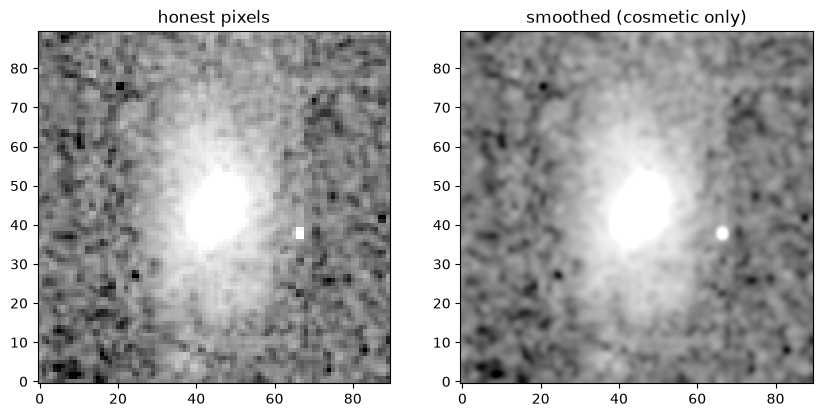

In [25]:
from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize

norm = ImageNormalize(sci, interval=ZScaleInterval(), stretch=AsinhStretch())

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(sci, origin="lower", cmap="gray", norm=norm, interpolation="nearest")
ax[0].set_title("honest pixels")
ax[1].imshow(sci, origin="lower", cmap="gray", norm=norm, interpolation="bicubic")
ax[1].set_title("smoothed (cosmetic only)")
plt.show()